In [ ]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
df= pd.read_csv("D:/UCI_Credit_Card.csv")
df

In [ ]:
target = 'default.payment.next.month'
features = [col for col in df.columns if col != target]

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df[features], df[target], test_size=0.2, stratify=df[target], random_state=42
)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    class_weights=[1,1]  # или [weight_neg, weight_pos]
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)


In [ ]:
df['P_pay'] = 1 - cat_model.predict_proba(df[features])[:,1]  # инвертируем дефолт

def risk_level(p):
    if p >= 0.7:
        return 'Low'
    elif p >= 0.4:
        return 'Medium'
    else:
        return 'High'

df['risk_level'] = df['P_pay'].apply(risk_level)

df['priority'] = df['P_pay'].rank(ascending=False)


In [ ]:
y_pred = calibrated_model.predict(X_val)
roc = roc_auc_score(y_val, calibrated_model.predict_proba(X_val)[:,1])
f1 = f1_score(y_val, y_pred)

print(f"ROC-AUC: {roc:.3f}, F1: {f1:.3f}")


final_table = df[['client_id', 'P_pay', 'risk_level', 'priority']]
final_table.to_csv("scoring_result.csv", index=False)

In [ ]:
data = pd.read_csv("C:/Users/aleks/AppData/Local/Programs/Microsoft VS Code/scoring_result.csv")
data

In [ ]:
!pip install ipywidgets

0:	test: 0.7403450	best: 0.7403450 (0)	total: 12.1ms	remaining: 6.02s
50:	test: 0.7753849	best: 0.7753849 (50)	total: 564ms	remaining: 4.96s
100:	test: 0.7791333	best: 0.7791333 (100)	total: 1.11s	remaining: 4.39s
150:	test: 0.7807748	best: 0.7808911 (147)	total: 1.59s	remaining: 3.68s
200:	test: 0.7805168	best: 0.7810281 (160)	total: 2.08s	remaining: 3.1s
250:	test: 0.7787787	best: 0.7810281 (160)	total: 2.57s	remaining: 2.55s
300:	test: 0.7784392	best: 0.7810281 (160)	total: 3.05s	remaining: 2.02s
350:	test: 0.7780846	best: 0.7810281 (160)	total: 3.53s	remaining: 1.5s
400:	test: 0.7776995	best: 0.7810281 (160)	total: 4s	remaining: 989ms
450:	test: 0.7772594	best: 0.7810281 (160)	total: 4.49s	remaining: 487ms
499:	test: 0.7770643	best: 0.7810281 (160)	total: 4.95s	remaining: 0us

bestTest = 0.7810281482
bestIteration = 160

Shrink model to first 161 iterations.
Recall на TRAIN: 0.810
Recall на VAL: 0.738


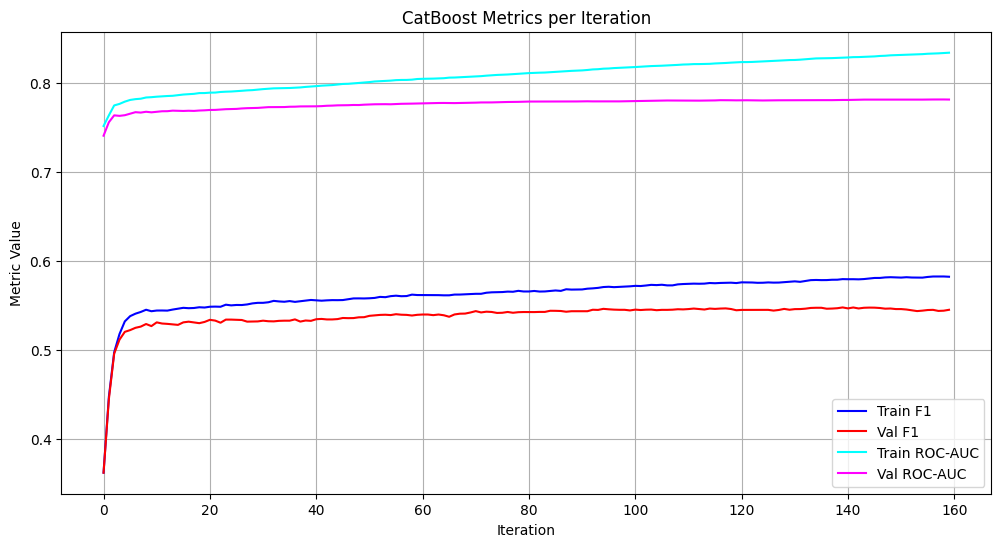

Файл scoring_result.csv готов ✅


In [96]:
# ===============================
# 1️⃣ Импорт библиотек
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import recall_score
from catboost import CatBoostRegressor

# ===============================
# 2️⃣ Загрузка датасета
# ===============================
df= pd.read_csv("D:/UCI_Credit_Card.csv")

# ===============================
# 3️⃣ Целевая переменная и признаки
# ===============================
target = 'default.payment.next.month'  # 1 = дефолт, 0 = погашение
features = [col for col in df.columns if col != target]

X_train, X_val, y_train, y_val = train_test_split(
    df[features], df[target], test_size=0.2, stratify=df[target], random_state=42
)
#pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) подбор весов
# ===============================
# 2️⃣ CatBoost
# ===============================
cat_model = CatBoostClassifier(
    iterations=500,  # чтобы было быстро
    learning_rate=0.05,
    depth=8,
    eval_metric='AUC',
    random_seed=43,
    verbose=50,
    class_weights=[1, 3],
    min_data_in_leaf=3,
    l2_leaf_reg=20
    )

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
cat_model.get_feature_importance()

best_iter = cat_model.get_best_iteration()
threshold = 0.48

# ===============================
# 3️⃣ F1 и ROC-AUC по итерациям
# ===============================
f1_train_list = []
f1_val_list = []
roc_train_list = []
roc_val_list = []
recall_train = recall_score(y_train, y_train_pred)
recall_val = recall_score(y_val, y_val_pred)

print(f"Recall на TRAIN: {recall_train:.3f}")
print(f"Recall на VAL: {recall_val:.3f}")

for i in range(1, best_iter+1):
    y_train_pred = (cat_model.predict_proba(X_train, ntree_end=i)[:,1] >= threshold).astype(int)
    y_val_pred = (cat_model.predict_proba(X_val, ntree_end=i)[:,1] >= threshold).astype(int)
    
    f1_train_list.append(f1_score(y_train, y_train_pred))
    f1_val_list.append(f1_score(y_val, y_val_pred))
    
    roc_train_list.append(roc_auc_score(y_train, cat_model.predict_proba(X_train, ntree_end=i)[:,1]))
    roc_val_list.append(roc_auc_score(y_val, cat_model.predict_proba(X_val, ntree_end=i)[:,1]))

# ===============================
# 4️⃣ График
# ===============================
plt.figure(figsize=(12,6))
plt.plot(f1_train_list, label='Train F1', color='blue')
plt.plot(f1_val_list, label='Val F1', color='red')
plt.plot(roc_train_list, label='Train ROC-AUC', color='cyan')
plt.plot(roc_val_list, label='Val ROC-AUC', color='magenta')
plt.xlabel('Iteration')
plt.ylabel('Metric Value')
plt.title('CatBoost Metrics per Iteration')
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# 5️⃣ P_pay, risk_level, priority и CSV
# ===============================
df['P_pay'] = 1 - cat_model.predict_proba(df[features])[:,1]

def risk_level(p):
    if p >= 0.7:
        return 'Low'
    elif p >= 0.4:
        return 'Medium'
    else:
        return 'High'

df['risk_level'] = df['P_pay'].apply(risk_level)
df['priority'] = df['P_pay'].rank(ascending=False)
df[['P_pay', 'risk_level', 'priority']].to_csv("scoring_result.csv", index=False)
print("Файл scoring_result.csv готов ✅")


# ПАРАМЕТРЫ
    iterations=500,  

    learning_rate=0.05,

    depth=4,

    eval_metric='AUC',

    random_seed=43,

    verbose=50,

    class_weights=[1, 2],

    min_data_in_leaf=10,

    l2_leaf_reg=2
# РЕЗУЛЬТАТ
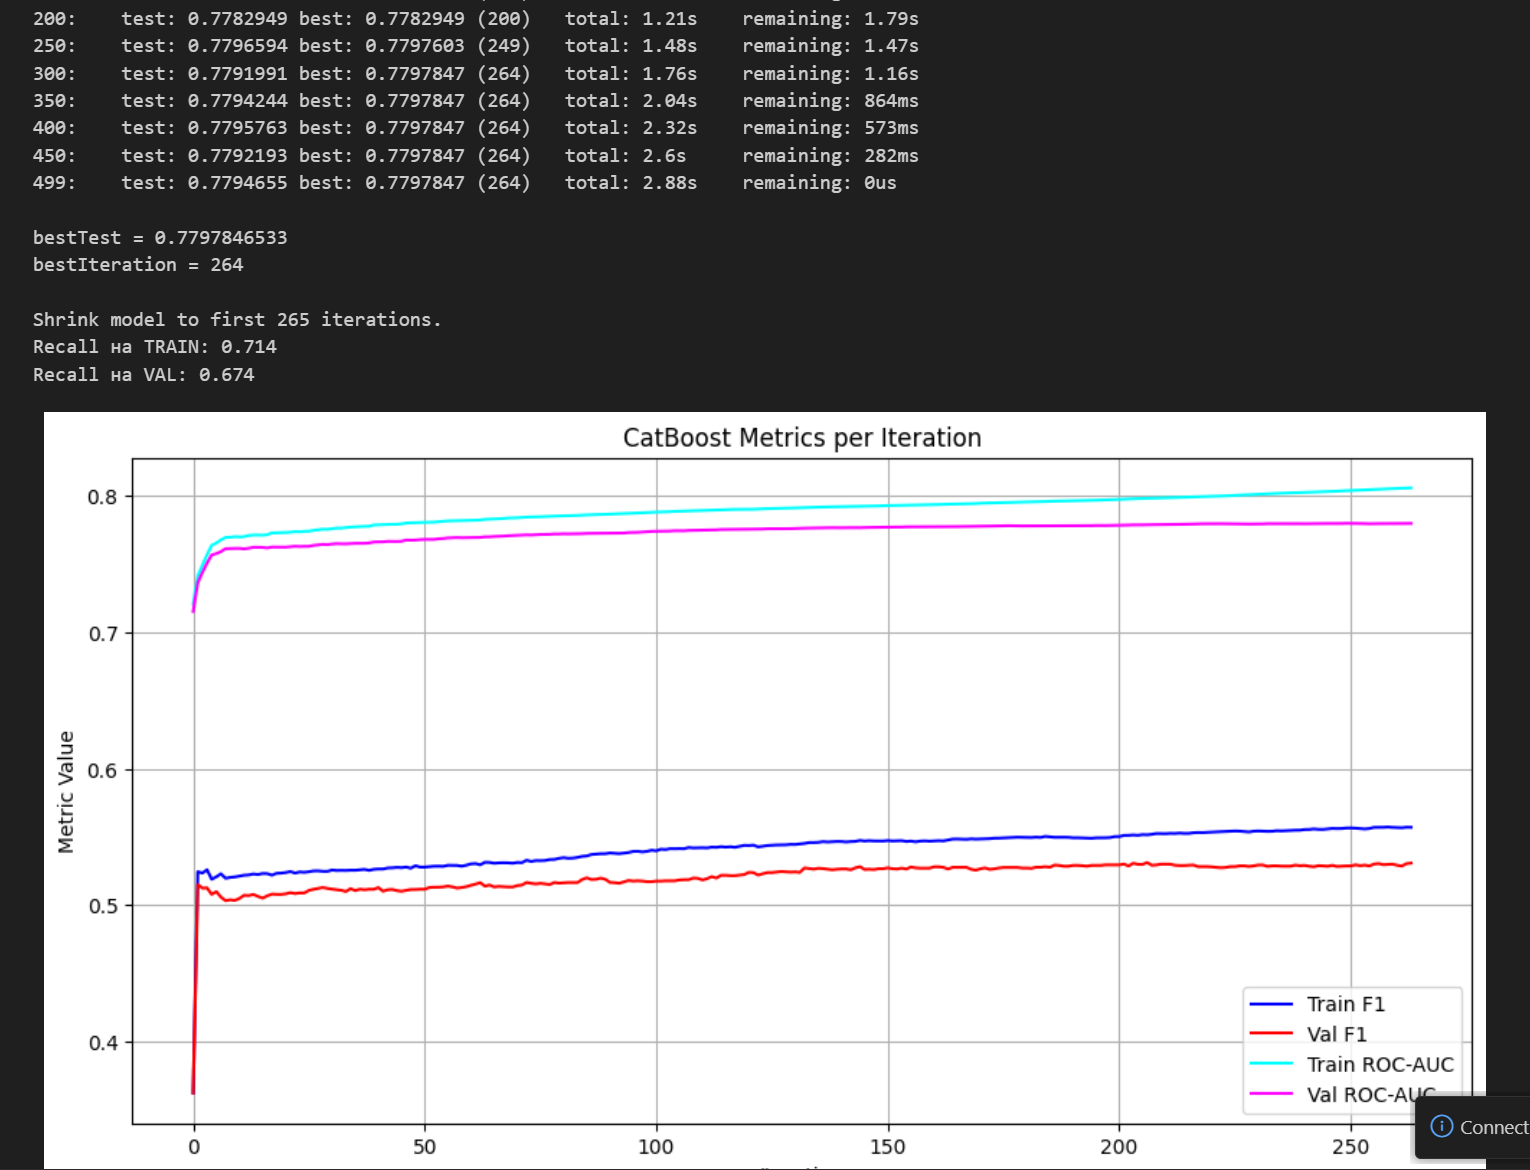

# ПАРАМЕТРЫ

    iterations=500,  

    learning_rate=0.05,

    depth=5,

    eval_metric='AUC',

    random_seed=43,

    verbose=50,

    class_weights=[1, 5],

    min_data_in_leaf=15,

    l2_leaf_reg=2

# РЕЗУЛЬТАТ
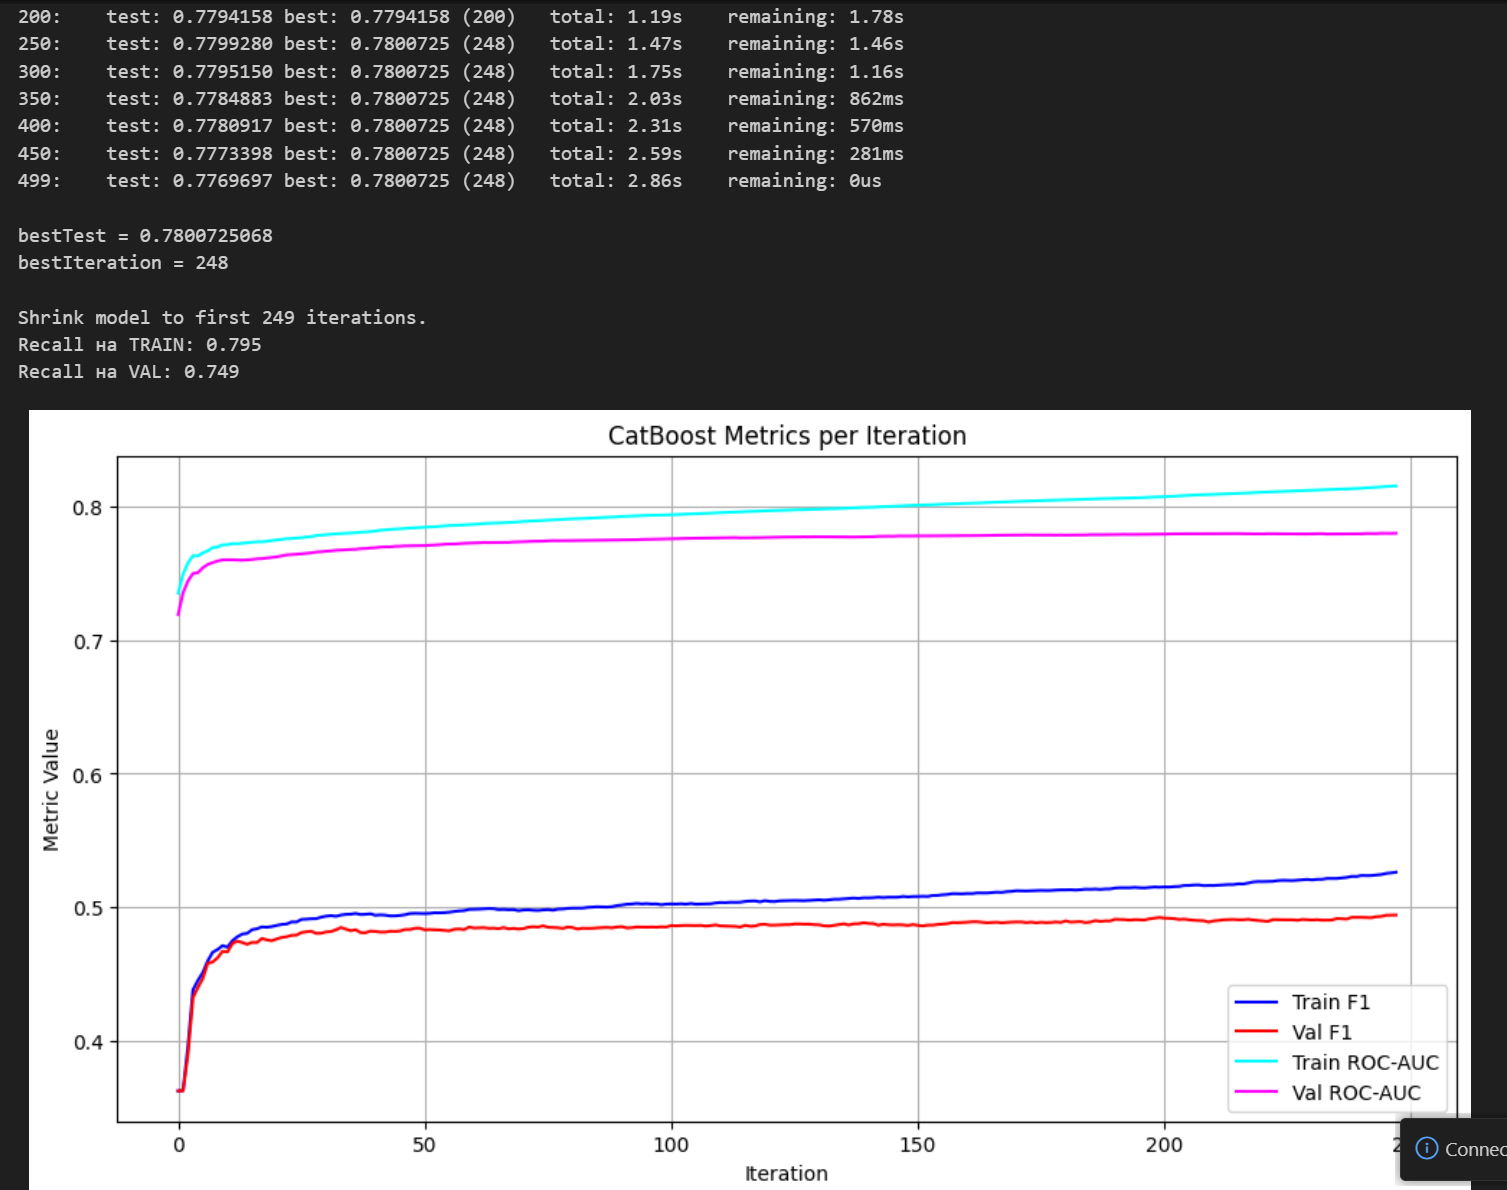